<a href="https://colab.research.google.com/github/sjakku-ai/DigitalTransformation/blob/main/Ecommerce_Image_Classifcation_Keras_May2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip '/content/Image_Classification_Ecommerce_Dataset.zip'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

# 1. Load the dataset
base_dir = '/content/ecommerce products'
img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"Categories found: {class_names}")

# 2. Configure for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 3. Build the model using MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False  # Freeze the pretrained weights

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(224, 224, 3)), # Preprocessing for MobileNetV2
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. Train the model
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Found 796 files belonging to 4 classes.
Using 637 files for training.
Found 796 files belonging to 4 classes.
Using 159 files for validation.
Categories found: ['jeans', 'sofa', 'tshirt', 'tv']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7033 - loss: 0.8070 - val_accuracy: 0.9245 - val_loss: 0.2569
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9780 - loss: 0.1470 - val_accuracy: 0.9874 - val_loss: 0.1139
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9890 - loss: 0.0686 - val_accuracy: 0.9937 - val_loss: 0.0783
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9906 - loss: 0.0525 - val_accuracy: 1.0000 - val_loss: 0.0580
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.9969 - loss: 0.0398 - val_accuracy: 1.0000 - val_loss: 0.0517
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.9953 - loss: 0.0313 - val_accuracy: 1.0000 - val_loss: 0.0421
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9937 - loss: 0.0335 - val_accuracy: 1.0000 - val_loss: 0.0385
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.9984 - loss: 0.0218 - val_accuracy: 1.00

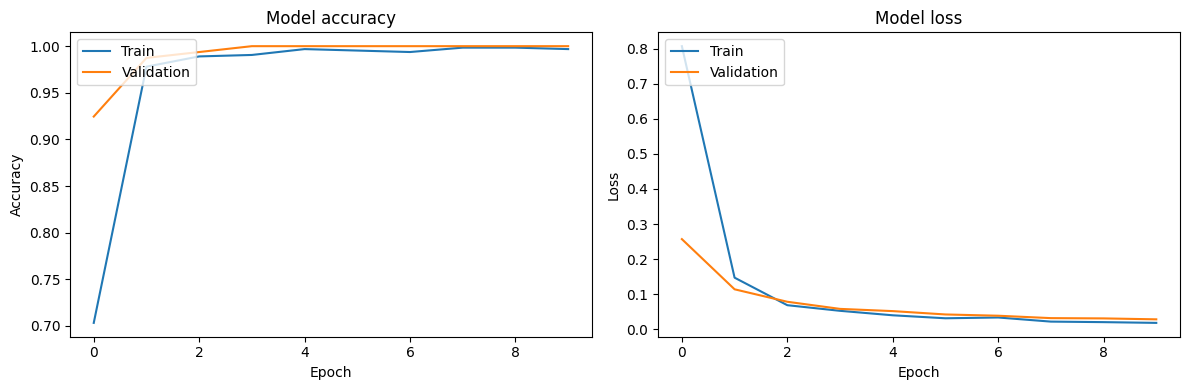

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


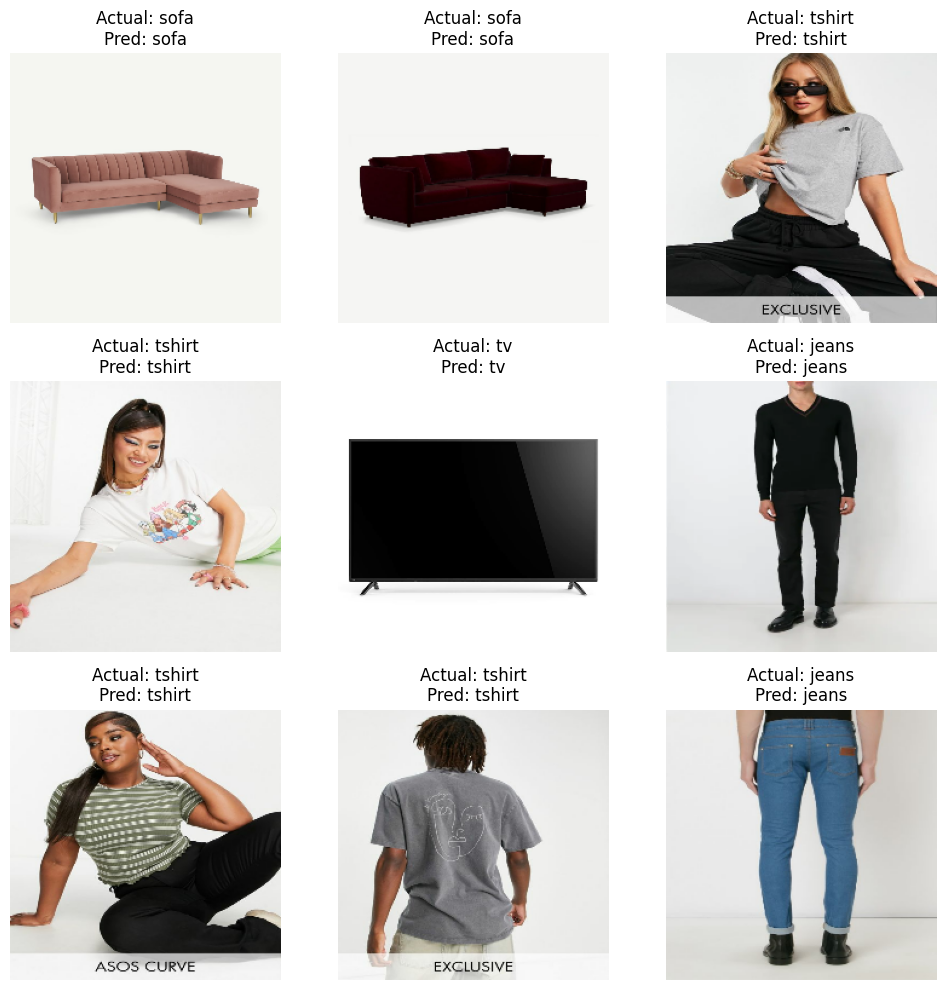

In [ ]:
import numpy as np

# Retrieve a batch of images from the validation set
image_batch, label_batch = next(iter(val_ds))
predictions = model.predict(image_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    actual_label = class_names[label_batch[i]]
    predict_label = class_names[np.argmax(predictions[i])]
    plt.title(f"Actual: {actual_label}\nPred: {predict_label}")
    plt.axis("off")
plt.tight_layout()

### Custom TensorFlow Training Loop (without Keras fit)
Below is the implementation using `tf.GradientTape` for manual optimization.

In [ ]:
import tensorflow as tf

# 1. Define the model architecture using Functional API/Subclassing logic
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Custom head
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(len(class_names))

# Preprocessing function
def preprocess(images):
    return tf.keras.applications.mobilenet_v2.preprocess_input(images)

# 2. Define Loss and Optimizer
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

# 3. Define the training step
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        # Forward pass
        preprocessed_images = preprocess(images)
        features = base_model(preprocessed_images, training=False)
        pooled_features = global_average_layer(features)
        logits = prediction_layer(pooled_features)
        loss = loss_object(labels, logits)

    # Backward pass
    gradients = tape.gradient(loss, prediction_layer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, prediction_layer.trainable_variables))

    train_loss(loss)
    train_accuracy(labels, logits)

# 4. Manual Training Loop
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_accuracy.reset_state()

    for images, labels in train_ds:
        train_step(images, labels)

    print(f'Epoch {epoch + 1}, Loss: {train_loss.result():.4f}, Accuracy: {train_accuracy.result() * 100:.2f}%')

Epoch 1, Loss: 0.8003, Accuracy: 68.45%
Epoch 2, Loss: 0.1414, Accuracy: 97.96%
Epoch 3, Loss: 0.0703, Accuracy: 98.59%
Epoch 4, Loss: 0.0466, Accuracy: 99.53%
Epoch 5, Loss: 0.0355, Accuracy: 99.84%
